In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import sys
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import lightgbm as lgb
import pickle
from utils import process_data_model_1_w_fk, process_data_model_2_w_fk
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, root_mean_squared_error
project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
from openap import prop
if project_root not in sys.path:
    sys.path.insert(0, project_root)
from atow_estimation.paths import PROCESSED_DATA_DIR

In [3]:
full_data = pd.read_csv(os.path.join(PROCESSED_DATA_DIR, "processed_dataset.csv"))

# data_m1 = pd.read_csv(os.path.join(PROCESSED_DATA_DIR, "processed_data_m1.csv"))
# data_m2 = pd.read_csv(os.path.join(PROCESSED_DATA_DIR, "processed_data_m2.csv"))

dataset_1_w_fk = process_data_model_1_w_fk(full_data)
dataset_1 = dataset_1_w_fk.drop(columns=['flightKey'])
dataset_2_w_fk = process_data_model_2_w_fk(full_data)
dataset_2 = dataset_2_w_fk.drop(columns=['flightKey'])

Rows with nan features dropped: 92
Rows with nan features dropped: 2


## Flights with climb trajectory

In [4]:
X = dataset_1.drop(['tow'], axis=1)
y = dataset_1['tow']

categorical_variables = ['routeType', 'flightType', 'wake', 'RECATwake', 'numberOfEngines', 'aircraftType', 'airlineCode']
numeric_cols = X.select_dtypes(include=['int64', 'float64']).columns.difference(categorical_variables)

for col in categorical_variables:
    if col in X.columns:
        X[col] = X[col].astype('category')
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)        

with open('../models/LightGBM_model_1.pkl', 'rb') as file:  
    model = pickle.load(file)
train_data = lgb.Dataset(X_train, label=y_train, categorical_feature=categorical_variables, free_raw_data=False)
val_data = lgb.Dataset(X_val, label=y_val, categorical_feature=categorical_variables, free_raw_data=False)
y_pred = model.predict(X_val)

In [5]:
r2 = r2_score(y_val, y_pred)
mae = mean_absolute_error(y_val, y_pred)
rmse = root_mean_squared_error(y_val, y_pred)
print(f"Mean Absolute Error: {mae:.2f}")
print(f"Root Mean Squared Error: {rmse:.2f}")
print(f"R^2 Score: {r2:.4f}")

Mean Absolute Error: 1306.37
Root Mean Squared Error: 2275.86
R^2 Score: 0.9959


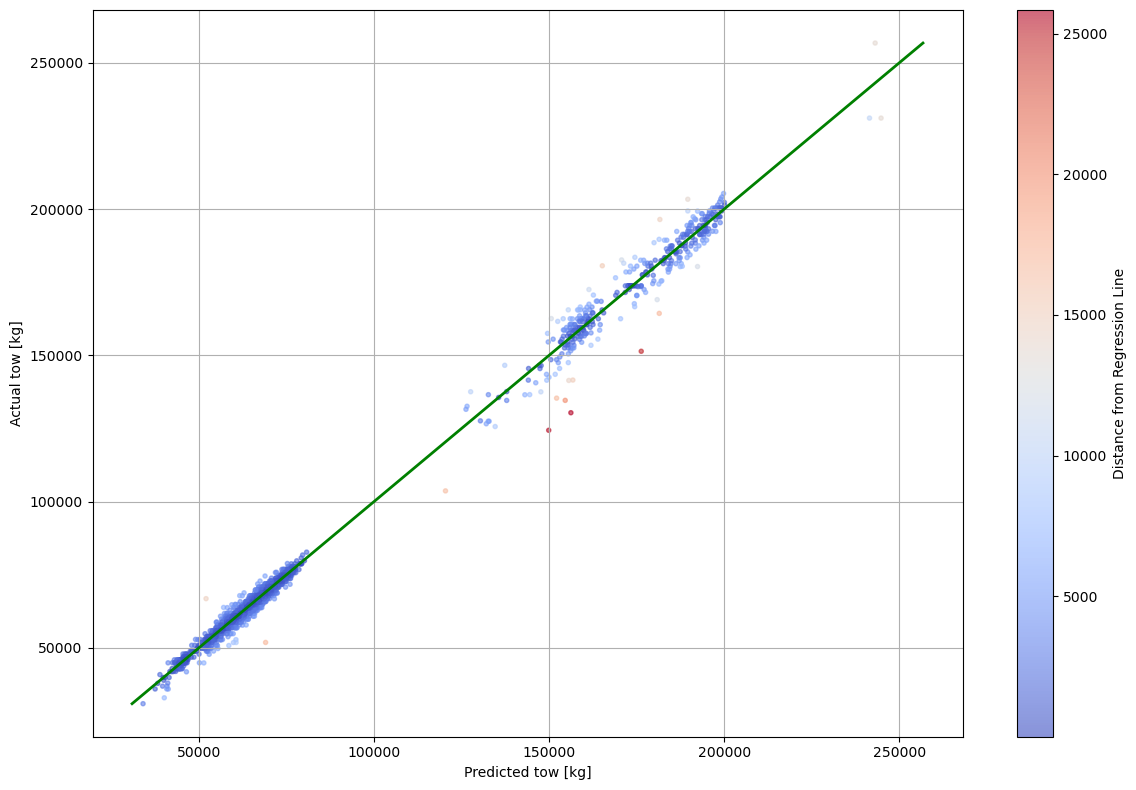

In [6]:
import numpy as np
from matplotlib.colors import Normalize

distances = np.abs(y_pred - y_val)
norm = Normalize(vmin=0, vmax=np.max(distances))
colors = plt.cm.coolwarm(norm(distances))  # colormap
plt.figure(figsize=(12, 8))
scatter = plt.scatter(x=y_pred, y=y_val, c=distances, cmap='coolwarm', marker='.', alpha=0.6)
plt.plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], 'g-', lw=2, label='Ideal')
plt.xlabel('Predicted tow [kg]')
plt.ylabel('Actual tow [kg]')
plt.grid(True)
# min_limit = 90000
# plt.xlim(right=min_limit) # Set the left (minimum) limit of the x-axis
# plt.ylim([40000, 90000])
cbar = plt.colorbar(scatter)
cbar.set_label('Distance from Regression Line')
plt.tight_layout()
plt.show()

In [7]:
threshold = 12500
errors = np.abs(y_val - y_pred)
high_errors = errors[errors > threshold]
high_error_indices = high_errors.index

df_errors = pd.DataFrame({
    'y_test': y_val,
    'y_pred': y_pred,
    'error': errors
})

df_high_error = df_errors.loc[high_error_indices]

In [8]:
high_error_fk = list(dataset_1_w_fk.join(df_high_error['y_pred']).loc[df_high_error.index]['flightKey'])
filtered_df = full_data[full_data['flightKey'].isin(high_error_fk)].merge(dataset_1_w_fk.join(df_high_error[['y_pred', 'error']]).loc[df_high_error.index][['flightKey', 'y_pred','error']], on=['flightKey'])

oews = []
for ac in filtered_df['aircraftType'].unique():
    ac_openap = prop.aircraft(ac, use_synonym=True)
    oews.append((ac, ac_openap['oew']))
    
oews_df = pd.DataFrame({
        'aircraftType': [obj[0] for obj in oews],
        'oew': [obj[1] for obj in oews],
    })

outliers = filtered_df.merge(oews_df, on=['aircraftType'])
outliers = outliers[['flightKey', 'aircraftType', 'wake', 'adep', 'ades', 'airlineCode', 'total_distance', 'flight_duration', 'oew', 'mtow', 'mlw', 'mfc', 'tow', 'y_pred', 'error']].sort_values(by='error')

### check similar flights to compare

In [9]:
num_similar_flights = []
for fk in outliers['flightKey']:
    flight = outliers[outliers['flightKey'] == fk]
    similar_flights = full_data[(full_data['adep'] == flight['adep'].values[0]) &  (full_data['ades'] == flight['ades'].values[0]) & (full_data['airlineCode'] == flight['airlineCode'].values[0]) & (full_data['aircraftType'] == flight['aircraftType'].values[0]) & (~full_data['flightKey'].isin(high_error_fk))][['flightKey', 'aircraftType', 'wake', 'adep', 'ades', 'airlineCode', 'total_distance', 'flight_duration', 'mtow', 'mlw', 'mfc', 'total_distance', 'tow']]
    # print(f"Num of flights similar to {flight['adep'].values[0]} -> {flight['ades'].values[0]} with airline: {flight['airlineCode'].values[0]}:", f'\t{len(similar_flights)}')
    num_similar_flights.append((fk, len(similar_flights)))
    
num_similar_flights_df = pd.DataFrame({
    'flightKey': [obj[0] for obj in num_similar_flights],
    'num_similar_flights': [obj[1] for obj in num_similar_flights],
})

In [10]:
for fk in outliers['flightKey']:
    flight = outliers[outliers['flightKey'] == fk]
    similar_flights = full_data[(full_data['adep'] == flight['adep'].values[0]) &  (full_data['ades'] == flight['ades'].values[0]) & (full_data['airlineCode'] == flight['airlineCode'].values[0]) & (full_data['aircraftType'] == flight['aircraftType'].values[0]) & (~full_data['flightKey'].isin(high_error_fk))]
    # features to compare
    if similar_flights.empty:
        continue  # Skip if no similar flights found to avoid errors

    # Compute diffs
    total_distance_diff = np.abs(flight['total_distance'].values[0] - similar_flights['total_distance'].mean())
    flight_duration_diff = np.abs(flight['flight_duration'].values[0] - similar_flights['flight_duration'].mean())
    tow_diff = np.abs(flight['tow'].values[0] - similar_flights['tow'].mean())
    
    # Compute variances
    total_distance_variance = similar_flights['total_distance'].var()
    flight_duration_variance = similar_flights['flight_duration'].var()
    tow_variance = similar_flights['tow'].var()    

    # Compute medians
    total_distance_median = similar_flights['total_distance'].median()
    flight_duration_median = similar_flights['flight_duration'].median()
    tow_median = similar_flights['tow'].median()
    
    # Assign to the correct row in outliers
    outliers.loc[outliers['flightKey'] == fk, 'total_distance_diff'] = total_distance_diff
    outliers.loc[outliers['flightKey'] == fk, 'flight_duration_diff'] = flight_duration_diff
    outliers.loc[outliers['flightKey'] == fk, 'tow_diff'] = tow_diff
    
    outliers.loc[outliers['flightKey'] == fk, 'total_distance_variance'] = total_distance_variance
    outliers.loc[outliers['flightKey'] == fk, 'flight_duration_variance'] = flight_duration_variance
    outliers.loc[outliers['flightKey'] == fk, 'tow_variance'] = tow_variance   
    
    outliers.loc[outliers['flightKey'] == fk, 'total_distance_median'] = total_distance_median
    outliers.loc[outliers['flightKey'] == fk, 'flight_duration_median'] = flight_duration_median
    outliers.loc[outliers['flightKey'] == fk, 'tow_median'] = tow_median             

In [11]:
outliers['cargo_weight'] = outliers['tow'] - outliers['oew']
outliers = outliers.merge(num_similar_flights_df, on=['flightKey'])

outliers[['flightKey', 'aircraftType', 'adep', 'ades', 'airlineCode', 
          'total_distance', 'total_distance_median', 'total_distance_diff', 'total_distance_variance', 
          'flight_duration', 'flight_duration_median', 'flight_duration_diff', 'flight_duration_variance',
          'oew', 'mtow', 'mlw', 'mfc', 'y_pred',
          'tow', 'tow_median', 'tow_diff', 'tow_variance', 'error', 'cargo_weight', 'num_similar_flights']]

,flightKey,aircraftType,adep,ades,airlineCode,total_distance,total_distance_median,total_distance_diff,total_distance_variance,flight_duration,...,mlw,mfc,y_pred,tow,tow_median,tow_diff,tow_variance,error,cargo_weight,num_similar_flights
0,18989745,B772,LEBL,EIDW,EIN,818.901853,818.391554,1.555388,45.368059,1.973889,...,213000,171000,243132.289250,256787.400000,256787.4,9164.550677,1.628094e+08,13655.110750,118787.400000,14
1,19004613,B772,LEBL,EIDW,EIN,818.836725,818.391554,1.620516,45.368059,1.989444,...,213000,171000,244820.466442,231126.658104,256787.4,16496.191219,1.628094e+08,13693.808338,93126.658104,14
2,18068728,B772,LEMD,KJFK,AAL,3155.562971,3130.002917,14.765425,705.144021,7.197778,...,213000,171000,189621.898750,203373.000000,192373.0,12060.877729,5.037062e+07,13751.101250,65373.000000,229
3,19388065,B788,LEBL,KPHL,AAL,3432.322417,3427.759959,0.413908,312.587998,7.792500,...,172000,126200,155641.651791,141421.000000,155517.5,13717.671875,5.052171e+07,14220.651791,22421.000000,128
4,18280425,B738,LEPA,EGCC,TOM,879.413714,880.482663,2.886485,34.979096,2.435833,...,66300,26000,52029.428067,66816.000000,67743.0,934.648352,1.830157e+07,14786.571933,25416.000000,91
5,18434895,B772,LEBL,KJFK,AAL,3349.454264,3348.086231,5.176891,456.649962,7.416389,...,213000,171000,181649.654161,196464.000000,191236.0,6429.972350,6.382076e+07,14814.345839,58464.000000,217
6,17984874,B788,LEBL,KPHL,AAL,3416.905725,3427.759959,15.830600,312.587998,8.178333,...,172000,126200,156799.042421,141562.000000,155517.5,13576.671875,5.052171e+07,15237.042421,22562.000000,128
7,18353362,B788,LEPA,EGBB,TOM,819.917787,819.508400,1.551502,83.267493,1.935000,...,172000,126200,165209.762320,180632.000000,156597.0,22750.085714,3.179101e+07,15422.237680,61632.000000,35
8,18207771,B763,LEIB,EGKK,TOM,757.396695,NaN,NaN,NaN,2.194444,...,136000,63200,120417.323396,103663.000000,NaN,NaN,NaN,16754.323396,13663.000000,0
9,19091083,A332,LEPA,EGBB,AEA,812.573186,NaN,NaN,NaN,2.096389,...,182000,139000,152153.316050,135373.000000,NaN,NaN,NaN,16780.316050,15173.000000,0


In [12]:
flight = outliers[outliers['flightKey'] == 20088120]
similar_flights = full_data[(full_data['adep'] == flight['adep'].values[0]) &  (full_data['ades'] == flight['ades'].values[0]) & (full_data['airlineCode'] == flight['airlineCode'].values[0]) & (full_data['aircraftType'] == flight['aircraftType'].values[0]) & (~full_data['flightKey'].isin(high_error_fk))]

17984874


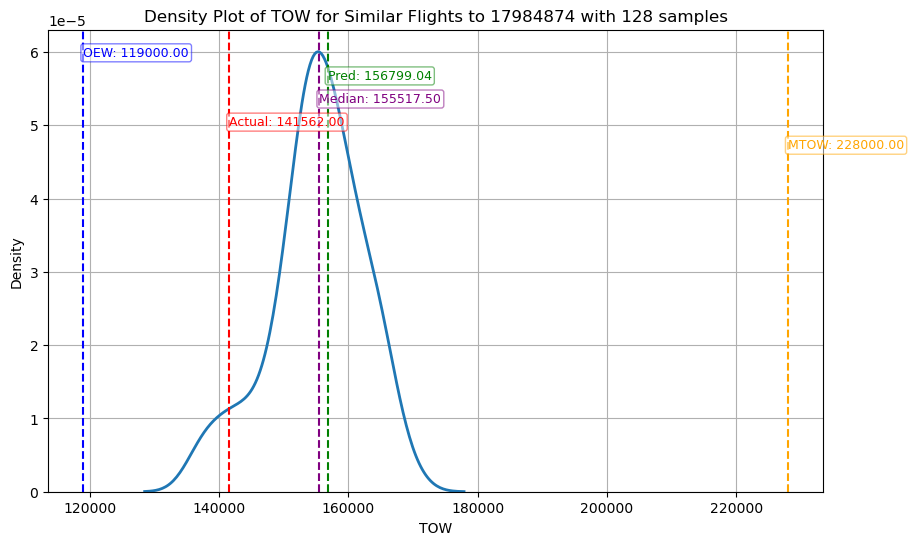

18353362


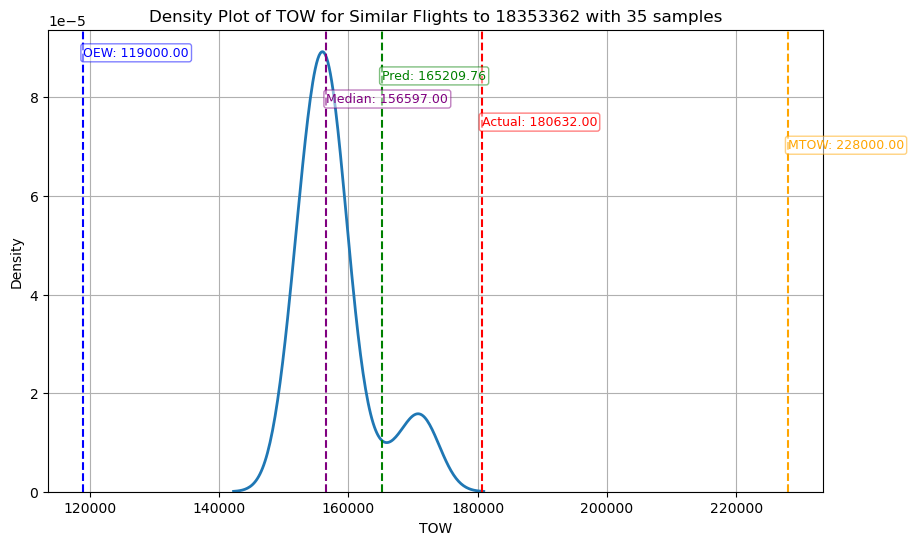

No similar flights found for flightKey 18207771. Skipping plot.
No similar flights found for flightKey 19091083. Skipping plot.
17977397


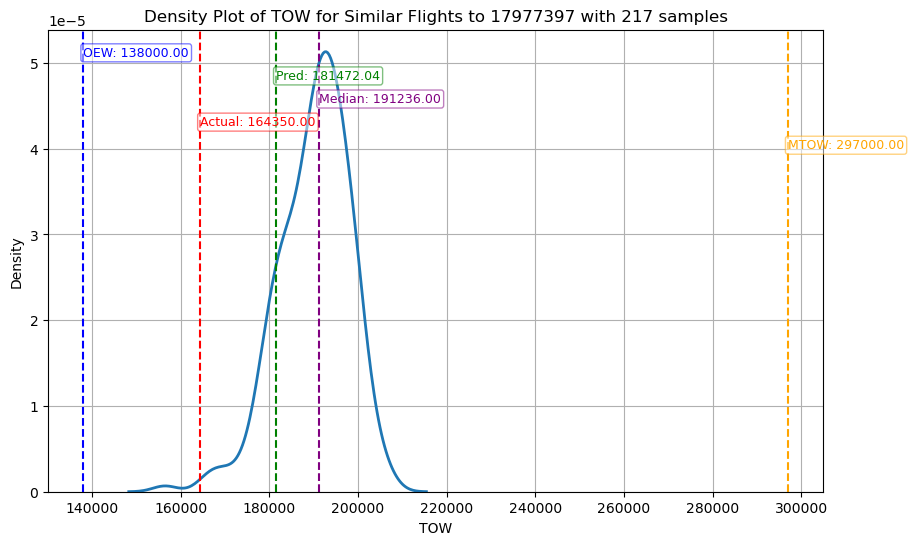

18657899


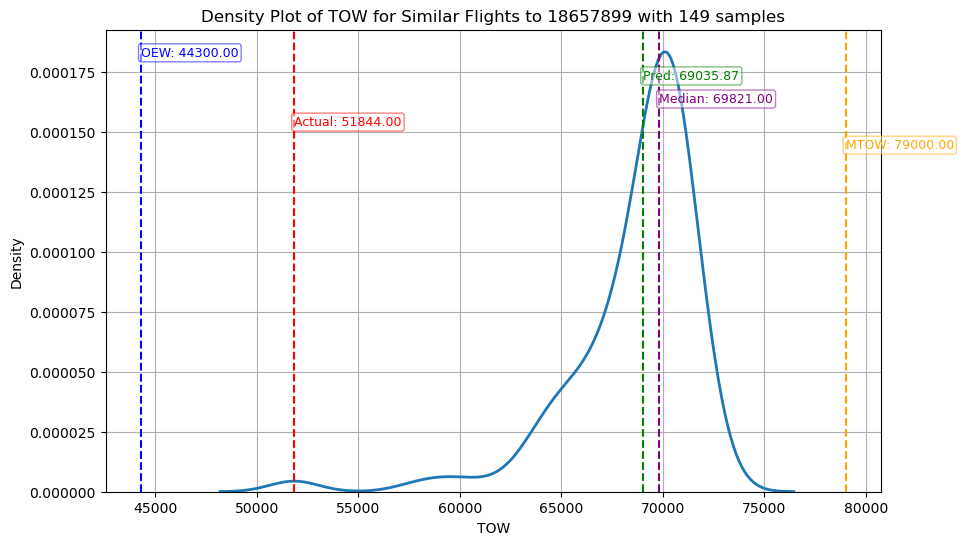

17979421


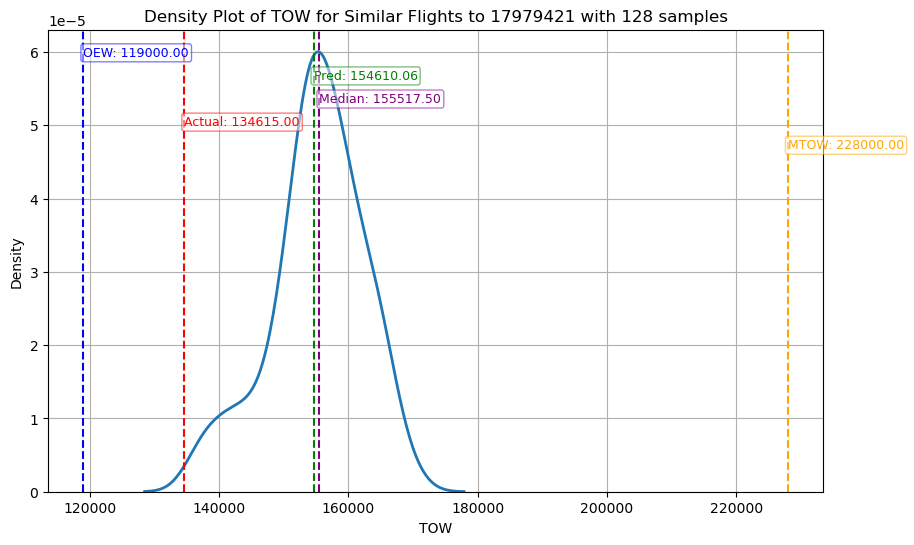

17660000


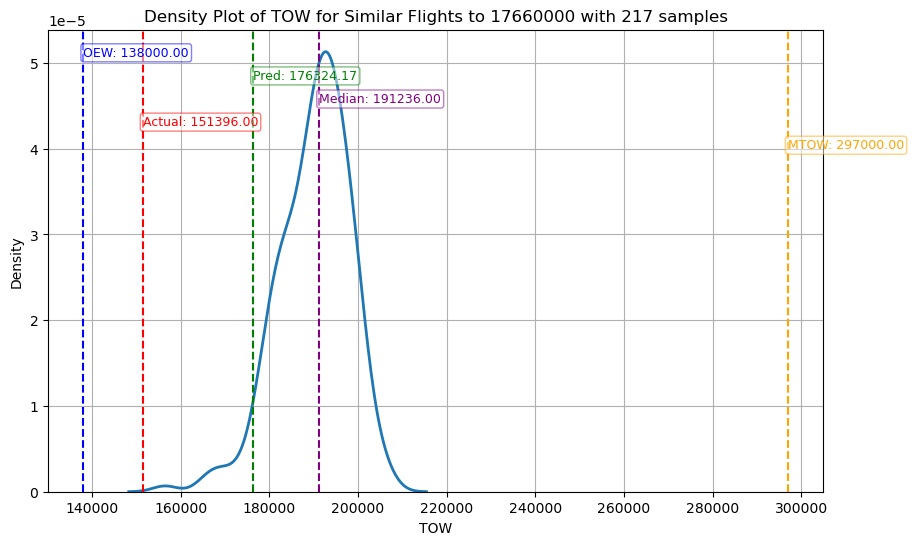

20088120


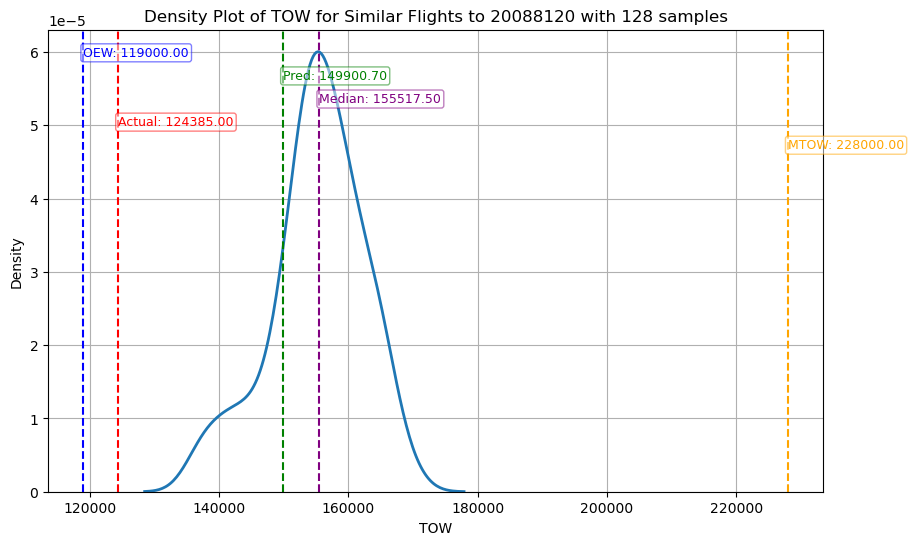

No similar flights found for flightKey 19353019. Skipping plot.


In [13]:
for fk in outliers[outliers['error'] > 15000]['flightKey']:
    flight = outliers[outliers['flightKey'] == fk]
    
    oew_value = flight['oew'].values[0]
    y_pred_value = flight['y_pred'].values[0]
    tow_median_value = flight['tow_median'].values[0]
    tow_value = flight['tow'].values[0]
    mtow_value = flight['mtow'].values[0]
    samples = flight['num_similar_flights'].values[0]
    
    similar_flights = full_data[(full_data['adep'] == flight['adep'].values[0]) &
                                (full_data['ades'] == flight['ades'].values[0]) &
                                (full_data['airlineCode'] == flight['airlineCode'].values[0]) &
                                (full_data['aircraftType'] == flight['aircraftType'].values[0]) &
                                (~full_data['flightKey'].isin(high_error_fk))]
    
    if not similar_flights.empty:
        print(fk)
        plt.figure(figsize=(10, 6))
        plt.title(f'Density Plot of TOW for Similar Flights to {fk} with {samples} samples')

        # Create the KDE plot
        sns.kdeplot(similar_flights['tow'], linewidth=2)

        # Get the current y-axis limits to position the text labels
        ymin, ymax = plt.ylim()

        # Define vertical positions for the text labels (staggered)
        # You can adjust these multipliers (0.95, 0.9, 0.85, etc.) based on how many lines you have
        # and how much vertical space you want between labels.
        text_y_positions = [ymax * 0.95, ymax * 0.9, ymax * 0.85, ymax * 0.8, ymax * 0.75]

        # Add vertical lines and text labels
        # Removed the 'label' argument from axvline

        plt.axvline(x=oew_value, color='blue', linestyle='--')
        plt.text(oew_value, text_y_positions[0], f'OEW: {oew_value:.2f}',
                 color='blue', ha='left', va='center', fontsize=9,
                 bbox=dict(boxstyle='round,pad=0.2', fc='white', ec='blue', alpha=0.5))

        plt.axvline(x=y_pred_value, color='green', linestyle='--')
        plt.text(y_pred_value, text_y_positions[1], f'Pred: {y_pred_value:.2f}',
                 color='green', ha='left', va='center', fontsize=9,
                 bbox=dict(boxstyle='round,pad=0.2', fc='white', ec='green', alpha=0.5))

        plt.axvline(x=tow_median_value, color='purple', linestyle='--')
        plt.text(tow_median_value, text_y_positions[2], f'Median: {tow_median_value:.2f}',
                 color='purple', ha='left', va='center', fontsize=9,
                 bbox=dict(boxstyle='round,pad=0.2', fc='white', ec='purple', alpha=0.5))

        plt.axvline(x=tow_value, color='red', linestyle='--')
        plt.text(tow_value, text_y_positions[3], f'Actual: {tow_value:.2f}',
                 color='red', ha='left', va='center', fontsize=9,
                 bbox=dict(boxstyle='round,pad=0.2', fc='white', ec='red', alpha=0.5))

        plt.axvline(x=mtow_value, color='orange', linestyle='--')
        plt.text(mtow_value, text_y_positions[4], f'MTOW: {mtow_value:.2f}',
                 color='orange', ha='left', va='center', fontsize=9,
                 bbox=dict(boxstyle='round,pad=0.2', fc='white', ec='orange', alpha=0.5))


        plt.grid(True)
        # Removed plt.legend()
        plt.xlabel('TOW')
        plt.ylabel('Density')
        plt.show()
    else:
        print(f"No similar flights found for flightKey {fk}. Skipping plot.")

---

## Flights with no climb trajectory

In [14]:
X = dataset_2.drop(['tow'], axis=1)
y = dataset_2['tow']

categorical_variables = ['routeType', 'flightType', 'wake', 'RECATwake', 'numberOfEngines', 'aircraftType', 'airlineCode']
numeric_cols = X.select_dtypes(include=['int64', 'float64']).columns.difference(categorical_variables)

for col in categorical_variables:
    if col in X.columns:
        X[col] = X[col].astype('category')
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)        

with open('../models/LightGBM_model_2.pkl', 'rb') as file:  
    model = pickle.load(file)
train_data = lgb.Dataset(X_train, label=y_train, categorical_feature=categorical_variables, free_raw_data=False)
val_data = lgb.Dataset(X_val, label=y_val, categorical_feature=categorical_variables, free_raw_data=False)
y_pred = model.predict(X_val)

In [15]:
r2 = r2_score(y_val, y_pred)
mae = mean_absolute_error(y_val, y_pred)
rmse = root_mean_squared_error(y_val, y_pred)
print(f"Mean Absolute Error: {mae:.2f}")
print(f"Root Mean Squared Error: {rmse:.2f}")
print(f"R^2 Score: {r2:.4f}")

Mean Absolute Error: 1462.86
Root Mean Squared Error: 2671.99
R^2 Score: 0.9949


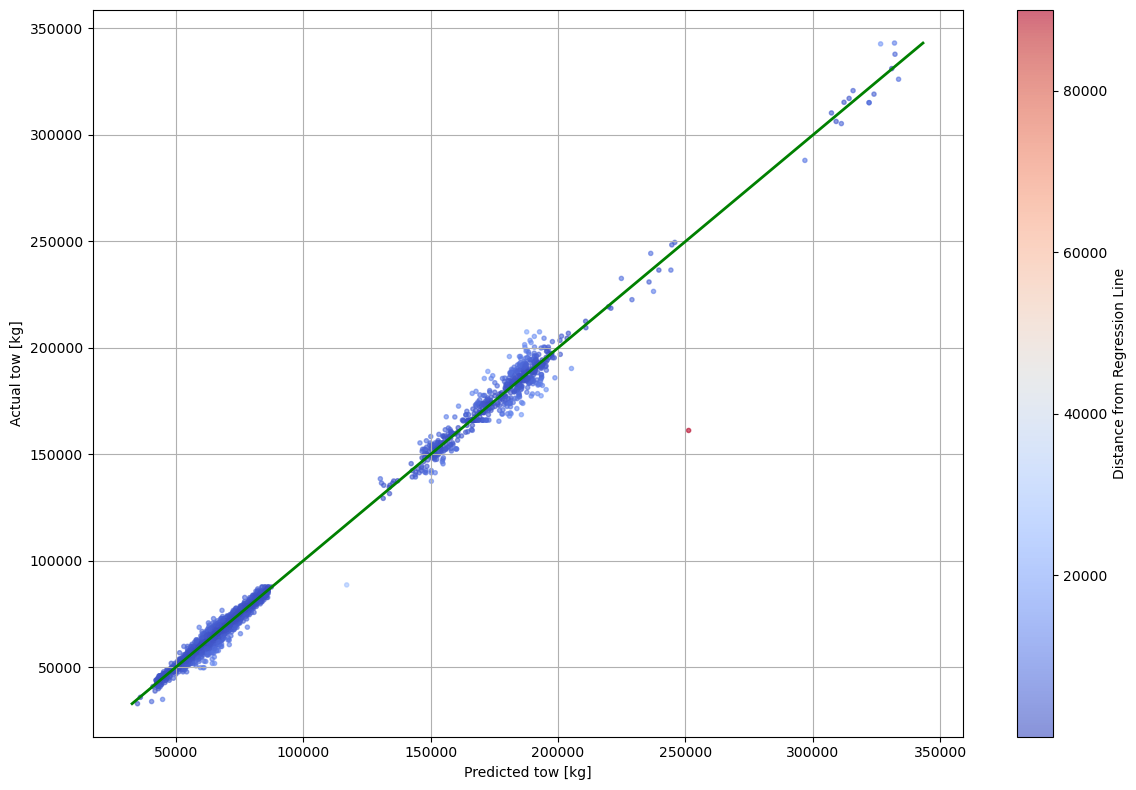

In [16]:
import numpy as np
from matplotlib.colors import Normalize

distances = np.abs(y_pred - y_val)
norm = Normalize(vmin=0, vmax=np.max(distances))
colors = plt.cm.coolwarm(norm(distances))  # colormap
plt.figure(figsize=(12, 8))
scatter = plt.scatter(x=y_pred, y=y_val, c=distances, cmap='coolwarm', marker='.', alpha=0.6)
plt.plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], 'g-', lw=2, label='Ideal')
plt.xlabel('Predicted tow [kg]')
plt.ylabel('Actual tow [kg]')
plt.grid(True)
cbar = plt.colorbar(scatter)
cbar.set_label('Distance from Regression Line')
plt.tight_layout()
plt.show()

In [17]:
threshold = 12500
errors = np.abs(y_val - y_pred)
high_errors = errors[errors > threshold]
high_error_indices = high_errors.index

df_errors = pd.DataFrame({
    'y_test': y_val,
    'y_pred': y_pred,
    'error': errors
})

df_high_error = df_errors.loc[high_error_indices]

In [18]:
high_error_fk = list(dataset_2_w_fk.join(df_high_error['y_pred']).loc[df_high_error.index]['flightKey'])
filtered_df = full_data[full_data['flightKey'].isin(high_error_fk)].merge(dataset_2_w_fk.join(df_high_error[['y_pred', 'error']]).loc[df_high_error.index][['flightKey', 'y_pred','error']], on=['flightKey'])

oews = []
for ac in filtered_df['aircraftType'].unique():
    ac_openap = prop.aircraft(ac, use_synonym=True)
    oews.append((ac, ac_openap['oew']))
    
oews_df = pd.DataFrame({
        'aircraftType': [obj[0] for obj in oews],
        'oew': [obj[1] for obj in oews],
    })

outliers = filtered_df.merge(oews_df, on=['aircraftType'])
outliers = outliers[['flightKey', 'aircraftType', 'wake', 'adep', 'ades', 'airlineCode', 'total_distance', 'flight_duration', 'oew', 'mtow', 'mlw', 'mfc', 'tow', 'y_pred', 'error']].sort_values(by='error')

### check similar flights to compare

In [19]:
num_similar_flights = []
for fk in outliers['flightKey']:
    flight = outliers[outliers['flightKey'] == fk]
    similar_flights = full_data[(full_data['adep'] == flight['adep'].values[0]) &  (full_data['ades'] == flight['ades'].values[0]) & (full_data['airlineCode'] == flight['airlineCode'].values[0]) & (full_data['aircraftType'] == flight['aircraftType'].values[0]) & (~full_data['flightKey'].isin(high_error_fk))][['flightKey', 'aircraftType', 'wake', 'adep', 'ades', 'airlineCode', 'total_distance', 'flight_duration', 'mtow', 'mlw', 'mfc', 'total_distance', 'tow']]
    # print(f"Num of flights similar to {flight['adep'].values[0]} -> {flight['ades'].values[0]} with airline: {flight['airlineCode'].values[0]}:", f'\t{len(similar_flights)}')
    num_similar_flights.append((fk, len(similar_flights)))
    
num_similar_flights_df = pd.DataFrame({
    'flightKey': [obj[0] for obj in num_similar_flights],
    'num_similar_flights': [obj[1] for obj in num_similar_flights],
})

In [20]:
for fk in outliers['flightKey']:
    flight = outliers[outliers['flightKey'] == fk]
    similar_flights = full_data[(full_data['adep'] == flight['adep'].values[0]) &  (full_data['ades'] == flight['ades'].values[0]) & (full_data['airlineCode'] == flight['airlineCode'].values[0]) & (full_data['aircraftType'] == flight['aircraftType'].values[0]) & (~full_data['flightKey'].isin(high_error_fk))]
    # features to compare
    if similar_flights.empty:
        continue  # Skip if no similar flights found to avoid errors

    # Compute diffs
    total_distance_diff = np.abs(flight['total_distance'].values[0] - similar_flights['total_distance'].mean())
    flight_duration_diff = np.abs(flight['flight_duration'].values[0] - similar_flights['flight_duration'].mean())
    tow_diff = np.abs(flight['tow'].values[0] - similar_flights['tow'].mean())
    
    # Compute variances
    total_distance_variance = similar_flights['total_distance'].var()
    flight_duration_variance = similar_flights['flight_duration'].var()
    tow_variance = similar_flights['tow'].var()    

    # Compute medians
    total_distance_median = similar_flights['total_distance'].median()
    flight_duration_median = similar_flights['flight_duration'].median()
    tow_median = similar_flights['tow'].median()
    
    # Assign to the correct row in outliers
    outliers.loc[outliers['flightKey'] == fk, 'total_distance_diff'] = total_distance_diff
    outliers.loc[outliers['flightKey'] == fk, 'flight_duration_diff'] = flight_duration_diff
    outliers.loc[outliers['flightKey'] == fk, 'tow_diff'] = tow_diff
    
    outliers.loc[outliers['flightKey'] == fk, 'total_distance_variance'] = total_distance_variance
    outliers.loc[outliers['flightKey'] == fk, 'flight_duration_variance'] = flight_duration_variance
    outliers.loc[outliers['flightKey'] == fk, 'tow_variance'] = tow_variance   
    
    outliers.loc[outliers['flightKey'] == fk, 'total_distance_median'] = total_distance_median
    outliers.loc[outliers['flightKey'] == fk, 'flight_duration_median'] = flight_duration_median
    outliers.loc[outliers['flightKey'] == fk, 'tow_median'] = tow_median             

In [21]:
outliers['cargo_weight'] = outliers['tow'] - outliers['oew']
outliers = outliers.merge(num_similar_flights_df, on=['flightKey'])

outliers[['flightKey', 'aircraftType', 'adep', 'ades', 'airlineCode', 
          'total_distance', 'total_distance_median', 'total_distance_diff', 'total_distance_variance', 
          'flight_duration', 'flight_duration_median', 'flight_duration_diff', 'flight_duration_variance',
          'oew', 'mtow', 'mlw', 'mfc', 'y_pred',
          'tow', 'tow_median', 'tow_diff', 'tow_variance', 'error', 'cargo_weight', 'num_similar_flights']]

,flightKey,aircraftType,adep,ades,airlineCode,total_distance,total_distance_median,total_distance_diff,total_distance_variance,flight_duration,...,mlw,mfc,y_pred,tow,tow_median,tow_diff,tow_variance,error,cargo_weight,num_similar_flights
0,18726440,A333,EIDW,LEBL,EIN,842.335496,856.036378,13.700882,297.012444,2.048056,...,188000,139000,181588.475961,169050.000000,167855.0,1195.000000,0.000000e+00,12538.475961,46270.000000,2
1,17592755,B772,KJFK,LEMD,AAL,3156.915484,3149.887214,1.689236,832.755042,6.497778,...,213000,171000,174388.030098,186940.000000,185940.0,1628.019324,4.872989e+07,12551.969902,48940.000000,207
2,20133719,B738,EGFF,LEMG,TOM,893.680899,895.951124,10.751083,384.356197,2.572222,...,66300,26000,64378.729725,51816.000000,67816.0,15095.090909,7.501395e+06,12562.729725,10416.000000,22
3,19993504,B772,KJFK,LEMD,AAL,3145.262263,3149.887214,9.963985,832.755042,6.525278,...,213000,171000,198775.003279,185940.000000,185940.0,628.019324,4.872989e+07,12835.003279,47940.000000,207
4,18181118,B788,KPHL,LEMD,AAL,3224.122898,3231.230219,11.822008,687.889948,6.809722,...,172000,126200,150312.343164,137368.000000,149368.0,11270.491803,3.122375e+07,12944.343164,18368.000000,122
5,19924837,B772,KJFK,LIRF,AAL,3813.294270,NaN,NaN,NaN,7.905278,...,213000,171000,180970.528120,167940.000000,NaN,NaN,NaN,13030.528120,29940.000000,0
6,18030162,B772,KDFW,LEMD,AAL,4318.213328,4345.338104,32.463112,329.923603,8.386389,...,213000,171000,189422.836160,202509.000000,191509.0,12407.407407,3.917379e+07,13086.163840,64509.000000,27
7,18643861,B772,LIRF,KDFW,AAL,4993.917795,4993.288391,0.868709,230.336599,10.674722,...,213000,171000,187014.889319,200327.000000,195327.0,3003.285714,1.697708e+07,13312.110681,62327.000000,7
8,18292550,A20N,ESSA,LEBL,SAS,1294.330920,1279.699854,12.391864,227.130352,3.449722,...,66000,29700,65260.068160,51813.000000,67813.0,14346.097561,1.855992e+07,13447.068160,7513.000000,41
9,17857879,B772,KMIA,LEBL,AAL,4101.749100,4104.182754,8.745163,530.945210,8.257778,...,213000,171000,191968.172098,178509.000000,187509.0,9325.757576,2.590071e+07,13459.172098,40509.000000,132


18592124


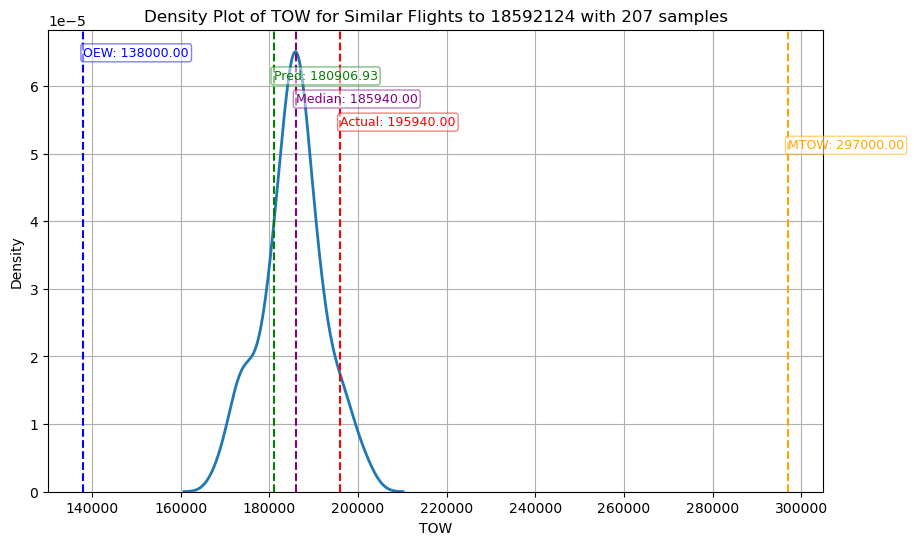

20127441


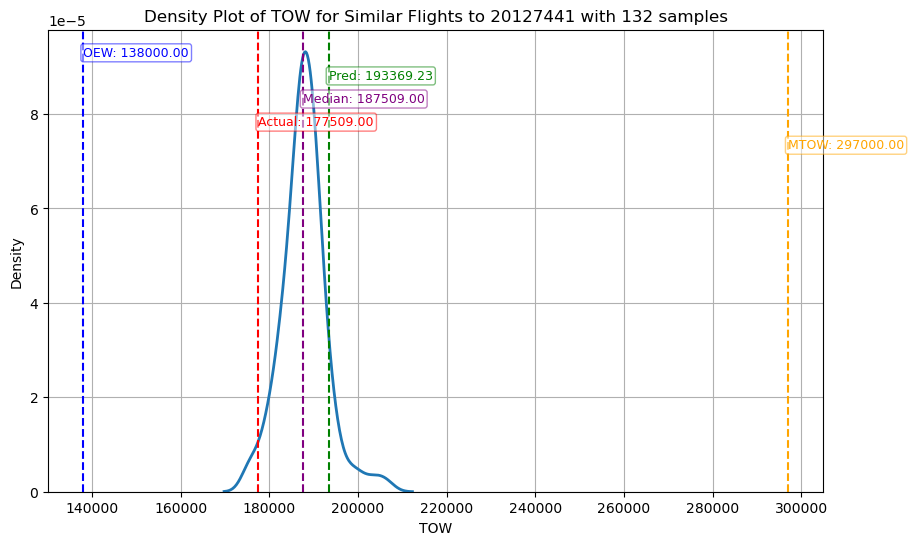

No similar flights found for flightKey 19238140. Skipping plot.
17552427


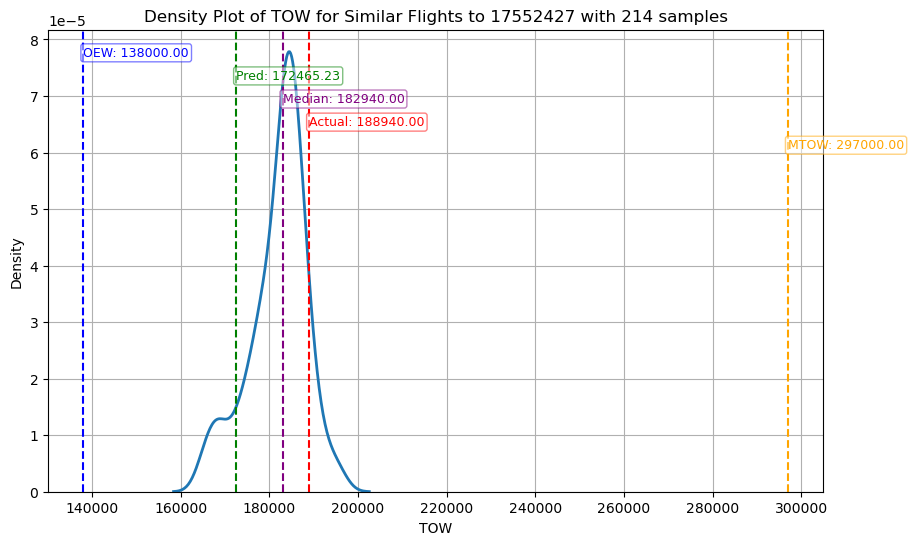

17829446


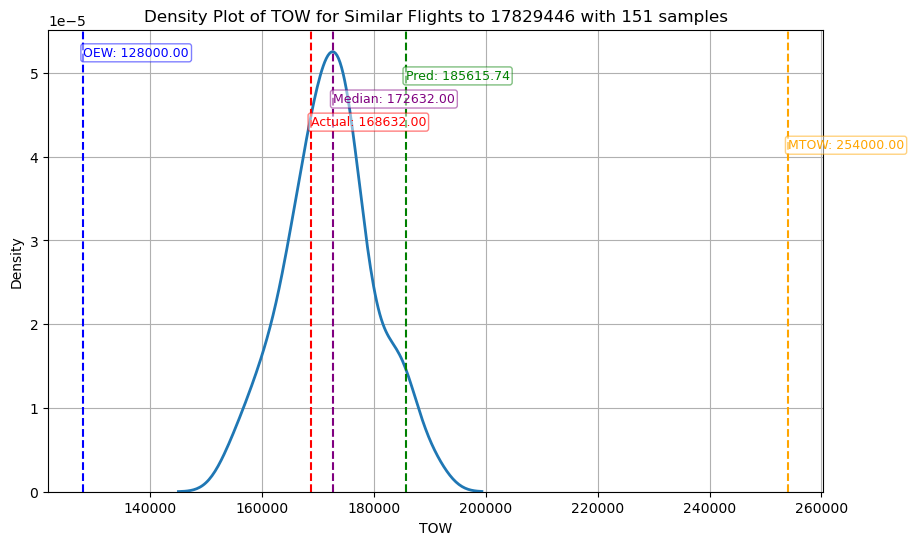

19334453


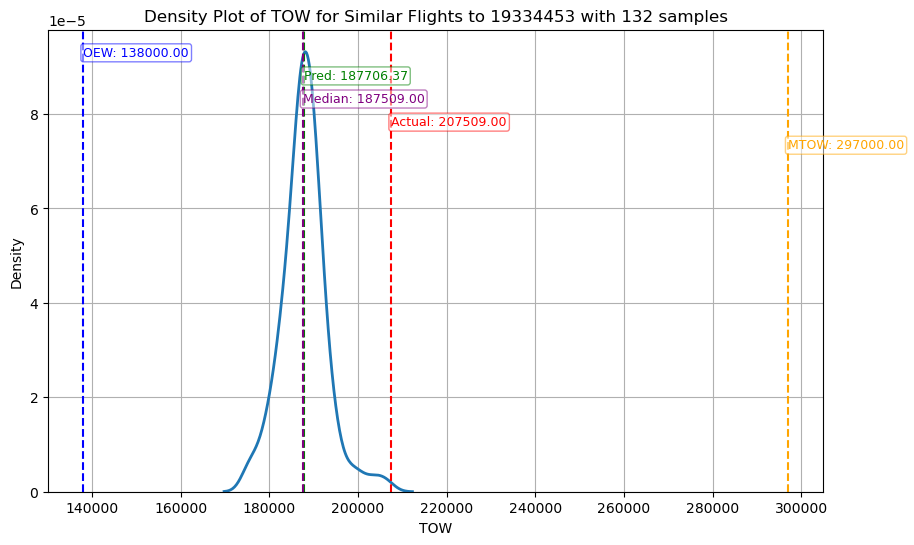

No similar flights found for flightKey 18753312. Skipping plot.
18890765


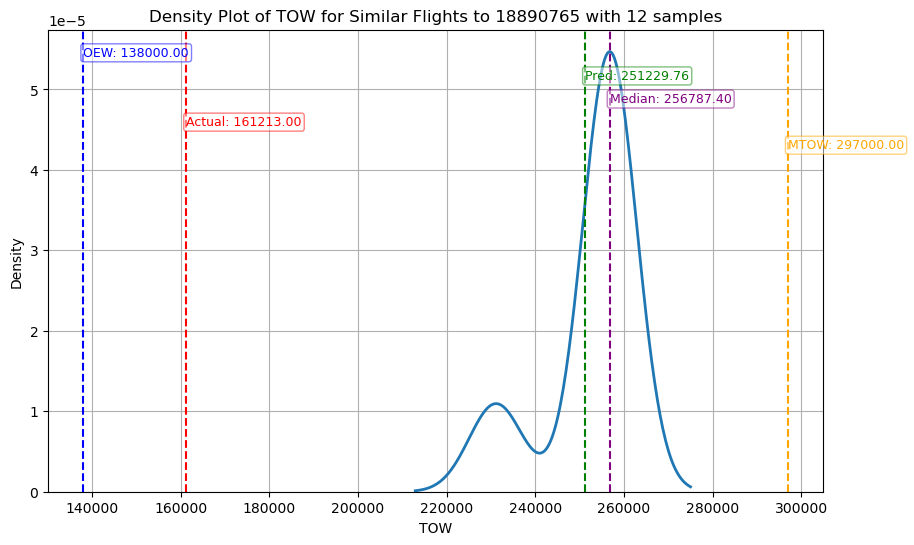

In [22]:
for fk in outliers[outliers['error'] > 15000]['flightKey']:
    flight = outliers[outliers['flightKey'] == fk]
    
    oew_value = flight['oew'].values[0]
    y_pred_value = flight['y_pred'].values[0]
    tow_median_value = flight['tow_median'].values[0]
    tow_value = flight['tow'].values[0]
    mtow_value = flight['mtow'].values[0]
    samples = flight['num_similar_flights'].values[0]
    
    similar_flights = full_data[(full_data['adep'] == flight['adep'].values[0]) &
                                (full_data['ades'] == flight['ades'].values[0]) &
                                (full_data['airlineCode'] == flight['airlineCode'].values[0]) &
                                (full_data['aircraftType'] == flight['aircraftType'].values[0]) &
                                (~full_data['flightKey'].isin(high_error_fk))]
    
    if not similar_flights.empty:
        print(fk)
        plt.figure(figsize=(10, 6))
        plt.title(f'Density Plot of TOW for Similar Flights to {fk} with {samples} samples')

        # Create the KDE plot
        sns.kdeplot(similar_flights['tow'], linewidth=2)

        # Get the current y-axis limits to position the text labels
        ymin, ymax = plt.ylim()

        # Define vertical positions for the text labels (staggered)
        # You can adjust these multipliers (0.95, 0.9, 0.85, etc.) based on how many lines you have
        # and how much vertical space you want between labels.
        text_y_positions = [ymax * 0.95, ymax * 0.9, ymax * 0.85, ymax * 0.8, ymax * 0.75]

        # Add vertical lines and text labels
        # Removed the 'label' argument from axvline

        plt.axvline(x=oew_value, color='blue', linestyle='--')
        plt.text(oew_value, text_y_positions[0], f'OEW: {oew_value:.2f}',
                 color='blue', ha='left', va='center', fontsize=9,
                 bbox=dict(boxstyle='round,pad=0.2', fc='white', ec='blue', alpha=0.5))

        plt.axvline(x=y_pred_value, color='green', linestyle='--')
        plt.text(y_pred_value, text_y_positions[1], f'Pred: {y_pred_value:.2f}',
                 color='green', ha='left', va='center', fontsize=9,
                 bbox=dict(boxstyle='round,pad=0.2', fc='white', ec='green', alpha=0.5))

        plt.axvline(x=tow_median_value, color='purple', linestyle='--')
        plt.text(tow_median_value, text_y_positions[2], f'Median: {tow_median_value:.2f}',
                 color='purple', ha='left', va='center', fontsize=9,
                 bbox=dict(boxstyle='round,pad=0.2', fc='white', ec='purple', alpha=0.5))

        plt.axvline(x=tow_value, color='red', linestyle='--')
        plt.text(tow_value, text_y_positions[3], f'Actual: {tow_value:.2f}',
                 color='red', ha='left', va='center', fontsize=9,
                 bbox=dict(boxstyle='round,pad=0.2', fc='white', ec='red', alpha=0.5))

        plt.axvline(x=mtow_value, color='orange', linestyle='--')
        plt.text(mtow_value, text_y_positions[4], f'MTOW: {mtow_value:.2f}',
                 color='orange', ha='left', va='center', fontsize=9,
                 bbox=dict(boxstyle='round,pad=0.2', fc='white', ec='orange', alpha=0.5))


        plt.grid(True)
        # Removed plt.legend()
        plt.xlabel('TOW')
        plt.ylabel('Density')
        plt.show()
    else:
        print(f"No similar flights found for flightKey {fk}. Skipping plot.")